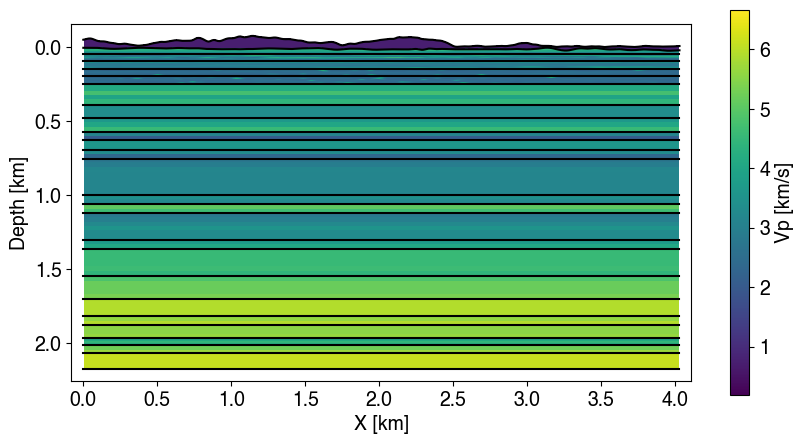

In [ ]:
import numpy as np
from frequensolve import *

project_path = "./scratch/ex_03/"

project = Project(
    name = "project",
    pretty_name = "Desert Simulation",
    path = project_path,
    load_if_exists = False
)

sim = SeismicSimulation(
    name      = "desert",
    physics   = "elastic",
    dimension = 2,
)
project += sim

# --- Model ---
model = LayeredModel(
    dimension = 2, 
    x_limits = [0.0, 4.029],
)

model.add_surface(
    name = "dune_topo",
    z = "desert_data/dune_topo.nc",
    z_ref = 0.0,
)

model.add_layer(
    name = "sand",
    properties = { 
        "Vp" : 0.731, 
        "Vs" : 0.3, 
        "Rho": 1.6,
        "Qp" : 50.0,
        "Qs" : 50.0,
    }
)
                
model.add_surface(
    name = "buried_topo",
    z = "desert_data/buried_topo.nc",
    z_ref = 0.025,
)

model.add_layer(
    name = "near_surface",
    properties = { 
        "Vp" : "desert_data/Vp_near.nc",
        "Vs" : "desert_data/Vs_near.nc",
        "Rho": "desert_data/Rho_near.nc",
        "Qp" : 100.0,
        "Qs" : 100.0,
    }
)

model.add_surface(z = 0.483e-1)
model.add_surface(z = 0.972e-1)
model.add_surface(z = 1.512e-1)
model.add_surface(z = 1.941e-1)
model.add_surface(z = 2.508e-1)

model.add_layer(
    name = "sub_surface",
    properties = { 
        "Vp" : "desert_data/Vp1D.nc",
        "Vs" : "desert_data/Vs1D.nc",
        "Rho": "desert_data/Rho1D.nc",
        "Qp" : 100.0,
        "Qs" : 100.0
    }
)

# Add lower surfaces
z_list = [ 3.9e-1, 4.791e-1, 5.712e-1, 6.312e-1, 6.99e-1, 
          7.551e-1, 9.981e-1, 1.059e0, 1.1211e0, 1.3032e0, 1.3662e0, 
          1.548e0, 1.7052e0, 1.8201e0, 1.881e0, 1.9692e0, 2.016e0,
          2.067e0, 2.1747e0 ]
for z in z_list:
    model.add_surface(z = z)
sim.model = model

model.plot(
    property = "Vp",
    resolution = [1000,1000],
    figsize = (10,5),
    fontsize = 14,
    aspect = "equal"
)

# --- Mesh ---
mesh = model.hex_mesh_generator(n = [4, 4])
sim += mesh


In [ ]:
# --- Boundary Conditions ---

BCs = BoundaryConditionManager(label_type = "geometric")

# Free surface BC
BCs += BoundaryCondition(
    name = "free_surface",
    kind = "neumann",
    boundaries = ["z_min"]
)

# Perfectly matched layer (absorbing boundary condition)
BCs += BoundaryCondition(
    name = "pml",
    kind = "pml",
    boundaries = ["x_min", "x_max", "z_max"],
    pml_wavelengths = 1.3,
    pml_exponent = 3.0,
    pml_constant = 40.0
)
sim += BCs

# --- Acquisition ---

acq = Acquisition()

# Source
acq.add_source_group(
    kind = "vector",
    coords = [[2.0, 0.0]],
    direction = [0.0, 1.0],
    frame = "reference"
)

# Receivers
device = ReceiverNode(name = "geophone")
device.add_component("u_z","displacement",[0.0, 1.0])
device.add_component("u_x","displacement",[1.0, 0.0])

coords = [ [x, 0.0] for x in np.linspace(0.0, 4.0, 1001)]

acq.add_receiver_group(
    name = "surface_geophones",
    device = device,
    coords = coords,
    frame = "reference"
)
sim += acq

# --- Discretization ---

method = Discretization(order = 4)
sim += method

# --- Solver Options ---

solver = SolverConfig(
    solve_on = "final",
    max_iter = 300,
    grids = 5,
    tolerance = 1.0e-4
)
sim += solver

# --- Outputs ---

out = OutputManager()
out += ParaviewOutput(
    name = "desert", 
    fields = ["displacement"], 
    upscale = 1
)
sim += out

project.save()

In [ ]:
site = "local"

# --- Connect to site ---
if site == "local":
    project.site = LocalSite()
elif site == "frontera":
    project.site = FronteraSite(rel_path = "FrequenSolve/ex_03/")
    project.site.attach_to_existing_job()

project.transfer()

# Create job for time domain simulation
job = TimeDomainJob(
    name = "fd_job",
    simulation = sim,
    f_min = 1.0,
    f_max = 10.0,
    T_max = 2.0
)

block = True
if block:
    # Blocking job submission
    results = project.submit_job(job)
else:
    # Asynchronous job submission
    future = project.submit_job_async(job)

    # ... do other work while waiting ...

    results = future.result() 

record_db = project.get_records(results)
up = 2
for record in record_db:
    wavelet = RickerWavelet(
        f0 = 3.0, 
        times = record.times(upscale = up), 
        causal = True,
    )
    shot = record.read_TD(wavelet, upscale = up)
    plot_gather(shot, A = 1)